# WTI-Brent statistical arbitrage with a Kalman-filter hedge ratio

West Texas Intermediate and Brent are the two crude oil benchmarks; their prices share a common stochastic trend, so the spread
between them should mean-revert. This notebook tests that idea on **official daily spot prices published by the U.S. Energy
Information Administration** (retrieved from FRED, series `DCOILWTICO` and `DCOILBRENTEU`).

1. Cointegration: Engle-Granger tests on the full sample and on rolling two-year windows, half-life of the spread.
2. Dynamic hedge ratio: Kalman filter with maximum-likelihood hyperparameters.
3. Trading rule with execution lag, stop-loss and transaction costs, evaluated in sample (1988-2009) and out of sample (2010-2025).
4. Parameter search on a grid run in parallel in C++, with the out-of-sample fate of the in-sample winner.
5. Robustness: costs and execution lag.
6. Overfitting diagnostics: probability of backtest overfitting (CSCV), deflated Sharpe ratio, bootstrap confidence intervals.
7. Robust variants: yearly walk-forward re-estimation of the filter and an adaptive standardisation of the signal.

**Strategy.** $y$ = WTI, $x$ = Brent. The Kalman filter tracks $y_t = \alpha_t + \beta_t x_t + e_t$ with random-walk coefficients;
the signal is the standardised one-step forecast error $z_t = e_t/\sqrt{S_t}$. Long spread (+1 barrel WTI, $-\beta$ barrels Brent)
when $z_t < -\text{entry}$, short when $z_t > \text{entry}$, exit when $z$ comes back within $\pm\text{exit}$, stop-loss at $|z| > 4$.
Profit and loss is in US dollars per barrel of WTI traded.

**Caveats.** Spot prices are not directly tradable: a real implementation would trade futures, with roll costs and basis risk.
WTI spot closed at -36.98 USD on 20 April 2020; the backtest keeps that observation, as it happened.

**Requirements.** `python -m pip install -e scripts/backtest_engine` (see the project README). **Data.** Downloaded from FRED into
`data/raw/fred/`; set `BACKTEST_ENGINE_DATA_MODE=synthetic` to run offline on a simulated cointegrated pair (not market data).

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repository root (used for data and output paths).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "backtest_engine").is_dir())
try:
    import backtest_engine
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "backtest_engine"))
    import backtest_engine
from backtest_engine import cointegration as ci, data, metrics as mt, strategies as st, synthetic

core = backtest_engine.require_cpp()

DATA_MODE = os.environ.get("BACKTEST_ENGINE_DATA_MODE", "official")  # "official" (EIA via FRED) or "synthetic"
START, END = "1988-01-01", "2025-12-31"
IN_SAMPLE_END = "2009-12-31"            # parameters are chosen on data up to this date
COST_PER_BARREL = 0.02                  # USD per barrel traded on each leg (about two futures ticks)
LAG = 1                                 # signal at the close of t, execution at the close of t + 1
STOP = 4.0                              # stop-loss on |z|
BURN_IN = 60                            # days ignored while the Kalman filter forgets its diffuse prior
DELTAS = [1e-6, 1e-5, 1e-4, 1e-3]
ENTRIES = [1.0, 1.5, 2.0, 2.5, 3.0]
EXITS = [0.0, 0.5, 1.0]
SEED = 20240517                         # stationary bootstrap
Z_HALFLIFE = 60                         # days, EWMA of squared forecast errors for the adaptive z-score
OUTPUT_DIR = ROOT / "outputs" / "wti_brent_pairs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
from backtest_engine.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"backtest_engine {backtest_engine.__version__} | data mode: {DATA_MODE} | threads: {os.cpu_count()}")

backtest_engine 0.1.0 | data mode: official | threads: 4


## 1. Data

Source: WTI crude oil spot price, Cushing, USD per barrel (EIA via FRED); Brent crude oil spot price, Europe, USD per barrel (EIA via FRED)
8,075 common trading days from 1988-01-04 to 2025-12-31; in sample: 4,155, out of sample: 3,920


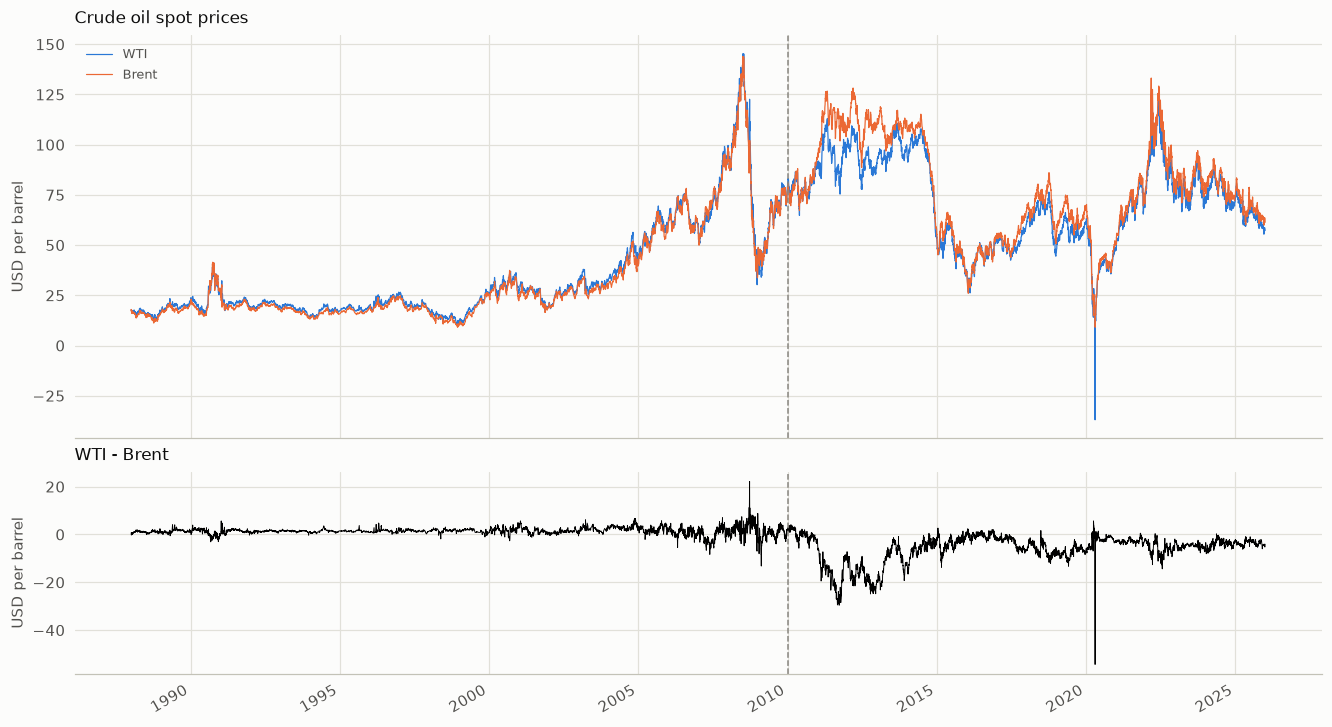

In [2]:
if DATA_MODE == "official":
    prices = data.load_fred(["DCOILWTICO", "DCOILBRENTEU"], start=START, end=END)
    source = prices.attrs["source"]
    prices = prices.dropna().rename(columns={"DCOILWTICO": "WTI", "DCOILBRENTEU": "Brent"})
else:
    pair = synthetic.cointegrated_pair(n=9500, start="1988-01-04")
    source = pair.attrs["source"]
    prices = pair.rename(columns={"y": "WTI", "x": "Brent"}).loc[START:END]
y, x = prices["WTI"], prices["Brent"]
in_sample = prices.index <= IN_SAMPLE_END
print("Source:", source)
print(f"{len(prices):,} common trading days from {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}; "
      f"in sample: {in_sample.sum():,}, out of sample: {(~in_sample).sum():,}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
prices.plot(ax=axes[0], lw=0.8)
axes[0].set(title="Crude oil spot prices", ylabel="USD per barrel")
axes[0].legend(loc="upper left")
(y - x).plot(ax=axes[1], lw=0.6, color="k")
axes[1].set(title="WTI - Brent", ylabel="USD per barrel")
for ax in axes:
    ax.axvline(pd.Timestamp(IN_SAMPLE_END), color=MUTED, ls="--", lw=1)
axes[1].set_xlabel("")
fig.savefig(OUTPUT_DIR / "prices.png", dpi=150)

## 2. Cointegration

Engle-Granger: OLS of WTI on a constant and Brent, then an ADF test (lag chosen by AIC) on the residuals, compared with the
critical values of MacKinnon (2010). The rolling test on two-year windows shows whether the long-run relation is stable.

,beta,alpha,ADF statistic,5% critical value,cointegrated at 5%,half-life (days)
in sample,0.9996,1.4037,-6.8607,-3.3376,True,3.3041
out of sample,0.8471,5.9556,-4.7732,-3.3377,True,10.4622
full sample,0.8884,4.0607,-4.9019,-3.3369,True,13.4491


Rolling two-year windows cointegrated at 5%: 61% of 361


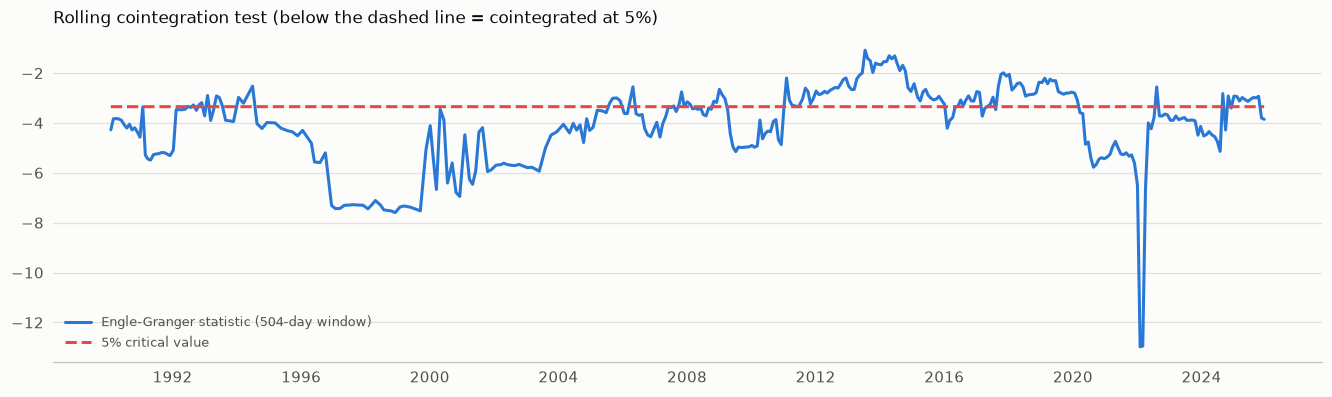

In [3]:
rows = {}
for label, mask in (("in sample", in_sample), ("out of sample", ~in_sample), ("full sample", np.ones(len(prices), bool))):
    eg = ci.engle_granger(y[mask], x[mask])
    rows[label] = {"beta": eg["beta"], "alpha": eg["alpha"], "ADF statistic": eg["statistic"],
                   "5% critical value": eg["critical_values"]["5%"], "cointegrated at 5%": eg["reject_5%"],
                   "half-life (days)": ci.half_life(eg["residuals"])}
display(pd.DataFrame(rows).T)

window, step = 504, 21
stats_, dates = [], []
for end in range(window, len(prices) + 1, step):
    eg = ci.engle_granger(y.iloc[end - window:end], x.iloc[end - window:end], max_lag=10)
    stats_.append((eg["statistic"], eg["critical_values"]["5%"], ci.half_life(eg["residuals"])))
    dates.append(prices.index[end - 1])
rolling = pd.DataFrame(stats_, index=dates, columns=["statistic", "critical 5%", "half-life"])
share = (rolling["statistic"] < rolling["critical 5%"]).mean()
print(f"Rolling two-year windows cointegrated at 5%: {share:.0%} of {len(rolling)}")

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(rolling.index, rolling["statistic"], label="Engle-Granger statistic (504-day window)")
ax.plot(rolling.index, rolling["critical 5%"], "--", color=NEGATIVE, label="5% critical value")
ax.set(title="Rolling cointegration test (below the dashed line = cointegrated at 5%)")
ax.legend(loc="lower left")
fig.savefig(OUTPUT_DIR / "rolling_cointegration.png", dpi=150)

## 3. Kalman-filter hedge ratio

The state noise $\delta$ and the observation variance are estimated by maximum likelihood (prediction-error decomposition,
computed in C++) on the in-sample period only. The filtered $\beta_t$ is compared with a one-year rolling OLS estimate.

MLE on the in-sample period: delta = 4.53e-04, observation variance = 0.0378 (0.03 s)


z: standard deviation 1.83, excess kurtosis 2573.2 (0 for a normal distribution)
Standard deviation of z by five-year period (1 if the model variance is well calibrated): {'1985-1989': 0.75, '1990-1994': 0.87, '1995-1999': 0.97, '2000-2004': 1.09, '2005-2009': 1.14, '2010-2014': 0.56, '2015-2019': 0.77, '2020-2024': 4.19, '2025-2029': 0.4}


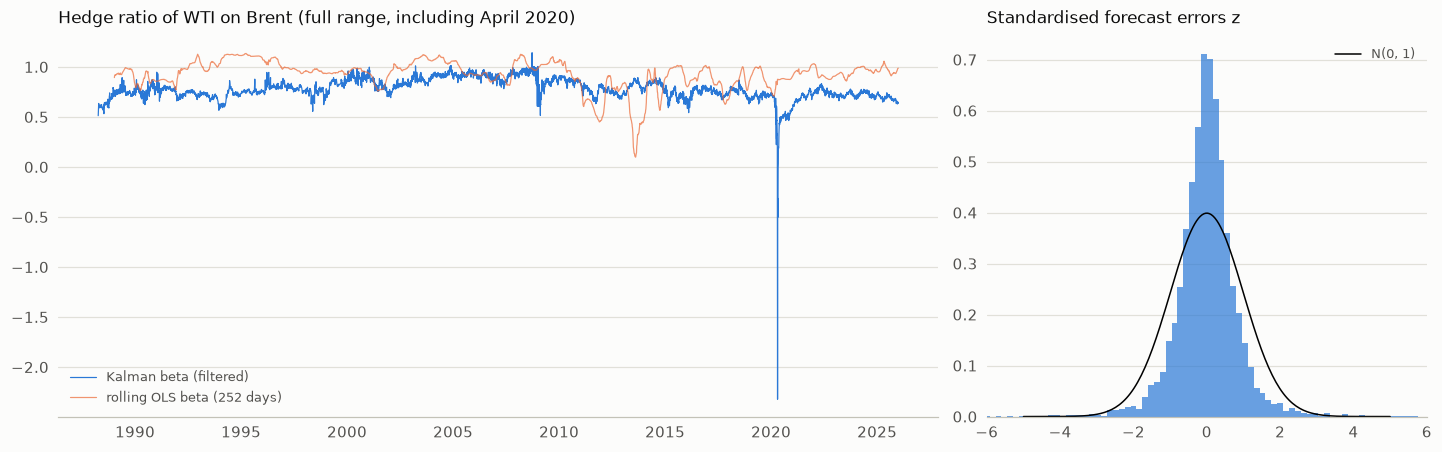

In [4]:
t0 = time.perf_counter()
mle = st.fit_kalman_mle(y[in_sample], x[in_sample], burn_in=BURN_IN)
print(f"MLE on the in-sample period: delta = {mle['delta']:.2e}, observation variance = {mle['obs_var']:.4f} "
      f"({time.perf_counter() - t0:.2f} s)")
signal = st.kalman_hedge(y, x, mle["delta"], mle["obs_var"])

cov = y.rolling(252).cov(x)
ols_beta = cov / x.rolling(252).var()
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(signal.index[BURN_IN:], signal["beta_filt"].iloc[BURN_IN:], lw=0.8, label="Kalman beta (filtered)")
axes[0].plot(ols_beta.index, ols_beta, lw=0.8, alpha=0.7, label="rolling OLS beta (252 days)")
axes[0].set(title="Hedge ratio of WTI on Brent (full range, including April 2020)")
axes[0].legend(loc="lower left")
z = signal["z"].iloc[BURN_IN:]
axes[1].hist(z.clip(-8, 8), bins=100, density=True, alpha=0.7)
grid = np.linspace(-5, 5, 200)
axes[1].plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "k", lw=1, label="N(0, 1)")
axes[1].set(title="Standardised forecast errors z", xlim=(-6, 6))
axes[1].legend(loc="upper right")
fig.savefig(OUTPUT_DIR / "kalman_hedge_ratio.png", dpi=150)
print(f"z: standard deviation {z.std():.2f}, excess kurtosis {z.kurt():.1f} (0 for a normal distribution)")
by_period = z.groupby((z.index.year // 5) * 5).std()
print("Standard deviation of z by five-year period (1 if the model variance is well calibrated):",
      {f"{k}-{k + 4}": round(v, 2) for k, v in by_period.items()})

## 4. A textbook configuration

Entry at $|z| > 2$, exit at $|z| < 0.5$, with the MLE hyperparameters. No parameter is tuned on the returns yet.

In [5]:
base = st.pairs_backtest(y, x, signal, entry=2.0, exit=0.5, stop=STOP, cost_per_unit=COST_PER_BARREL, lag=LAG, start=BURN_IN)
summary = pd.DataFrame({label: mt.performance_summary(base["pnl"][mask], additive=True)
                        for label, mask in (("in sample", in_sample), ("out of sample", ~in_sample))}).T
summary = summary.rename(columns={"annual mean": "annual P&L (USD)", "annual volatility": "annual s.d. (USD)",
                                  "max drawdown": "max drawdown (USD)"})
display(summary[["annual P&L (USD)", "annual s.d. (USD)", "Sharpe", "max drawdown (USD)", "hit rate", "skewness", "observations"]])
print(f"Trades: {base.attrs['n_trades']}, stop-losses: {base.attrs['n_stops']}")

,annual P&L (USD),annual s.d. (USD),Sharpe,max drawdown (USD),hit rate,skewness,observations
in sample,1.5484,5.0207,0.3084,11.7100,0.2827,5.0791,"4,155.0000"
out of sample,2.8465,12.5462,0.2269,9.6716,0.2788,56.9789,"3,920.0000"


Trades: 192, stop-losses: 5


## 5. Parameter search in sample, evaluation out of sample

The grid combines every $\delta$, entry and exit threshold (plus the MLE $\delta$); the C++ engine runs all configurations in
parallel over the whole sample, and we then split each P&L series into the two periods. The configuration with the best in-sample
Sharpe ratio is "what a researcher would publish"; its out-of-sample Sharpe ratio is what an investor would get.

70 configurations x 8,075 days in 0.01 s (C++)
In-sample winner: d=0.0001 in=3 out=1
  Sharpe in sample 0.57 -> out of sample 0.18 (rank 39 of 70); median out-of-sample Sharpe of all configurations 0.19
Correlation of in-sample and out-of-sample Sharpe ratios across configurations: 0.21


,delta,entry,exit,n_trades,Sharpe in sample,Sharpe out of sample
d=0.0001 in=3 out=1,0.0001,3.0000,1.0000,284,0.5654,0.1764
d=0.0001 in=3 out=0.5,0.0001,3.0000,0.5000,284,0.5581,0.1854
d=0.000453 in=1.5 out=1,0.0005,1.5000,1.0000,369,0.5131,0.2561
d=0.0001 in=3 out=0,0.0001,3.0000,0.0000,280,0.4915,0.2018
d=0.000453 in=1.5 out=0,0.0005,1.5000,0.0000,353,0.4784,0.2296
d=0.000453 in=1.5 out=0.5,0.0005,1.5000,0.5000,364,0.4695,0.2433
d=0.0001 in=2.5 out=1,0.0001,2.5000,1.0000,449,0.4397,0.2743
d=0.0001 in=2.5 out=0.5,0.0001,2.5000,0.5000,443,0.4229,0.2910
d=0.0001 in=2.5 out=0,0.0001,2.5000,0.0000,435,0.3865,0.3044
d=0.000453 in=1 out=0,0.0005,1.0000,0.0000,813,0.3748,0.2633


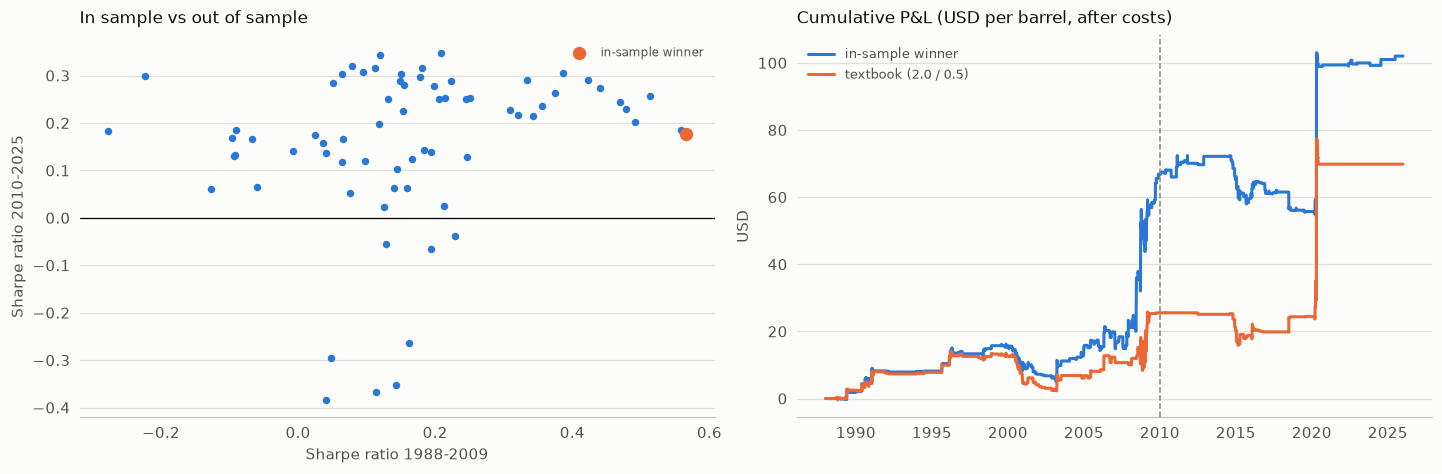

In [6]:
t0 = time.perf_counter()
grid_pnl, configs = st.pairs_grid(y, x, DELTAS + [mle["delta"]], mle["obs_var"], ENTRIES, EXITS,
                                  stop=STOP, cost_per_unit=COST_PER_BARREL, lag=LAG, start=BURN_IN)
print(f"{len(configs)} configurations x {len(grid_pnl):,} days in {time.perf_counter() - t0:.2f} s (C++)")
configs["Sharpe in sample"] = grid_pnl[in_sample].apply(mt.sharpe_ratio)
configs["Sharpe out of sample"] = grid_pnl[~in_sample].apply(mt.sharpe_ratio)
best = configs["Sharpe in sample"].idxmax()
rank = configs["Sharpe out of sample"].rank(ascending=False)[best]
print(f"In-sample winner: {best}")
print(f"  Sharpe in sample {configs.loc[best, 'Sharpe in sample']:.2f} -> out of sample {configs.loc[best, 'Sharpe out of sample']:.2f} "
      f"(rank {rank:.0f} of {len(configs)}); median out-of-sample Sharpe of all configurations {configs['Sharpe out of sample'].median():.2f}")
print(f"Correlation of in-sample and out-of-sample Sharpe ratios across configurations: "
      f"{configs['Sharpe in sample'].corr(configs['Sharpe out of sample']):.2f}")
display(configs.sort_values("Sharpe in sample", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].scatter(configs["Sharpe in sample"], configs["Sharpe out of sample"], s=15)
axes[0].scatter(configs.loc[best, "Sharpe in sample"], configs.loc[best, "Sharpe out of sample"], color=SERIES[1], s=60,
                zorder=3, label="in-sample winner")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set(xlabel="Sharpe ratio 1988-2009", ylabel="Sharpe ratio 2010-2025", title="In sample vs out of sample")
axes[0].legend(fontsize=8)
axes[1].plot(grid_pnl[best].cumsum(), label="in-sample winner")
axes[1].plot(base["pnl"].cumsum(), label="textbook (2.0 / 0.5)")
axes[1].axvline(pd.Timestamp(IN_SAMPLE_END), color=MUTED, ls="--", lw=1)
axes[1].set(title="Cumulative P&L (USD per barrel, after costs)", ylabel="USD")
axes[1].legend(loc="upper left")
fig.savefig(OUTPUT_DIR / "grid_search.png", dpi=150)

## 6. Transaction costs and execution lag

Out-of-sample Sharpe ratio of the in-sample winner for different costs per barrel and execution delays. A lag of 0 assumes trading
at the same close that generated the signal, which is not achievable in practice.

In [7]:
row = configs.loc[best]
best_signal = st.kalman_hedge(y, x, row["delta"], mle["obs_var"])
table = {}
for lag in (0, 1, 2):
    table[f"lag {lag}"] = {f"{c:.2f} USD": mt.sharpe_ratio(st.pairs_backtest(y, x, best_signal, row["entry"], row["exit"], STOP, c, lag, BURN_IN)["pnl"][~in_sample])
                           for c in (0.0, 0.01, 0.02, 0.05, 0.10)}
sensitivity = pd.DataFrame(table).T
sensitivity.columns.name = "cost per barrel"
display(sensitivity)

# A single episode can dominate a spread strategy: WTI spot turned negative in April 2020.
episode = (prices.index >= "2020-04-01") & (prices.index <= "2020-05-31")
oos_pnl = grid_pnl[best][~in_sample]
print(f"Out-of-sample P&L of the in-sample winner: {oos_pnl.sum():.1f} USD, of which April-May 2020: "
      f"{grid_pnl[best][episode].sum():.1f} USD")
print(f"Out-of-sample Sharpe excluding April-May 2020: {mt.sharpe_ratio(grid_pnl[best][~in_sample & ~episode]):.2f} "
      f"(including it: {mt.sharpe_ratio(oos_pnl):.2f})")

cost per barrel,0.00 USD,0.01 USD,0.02 USD,0.05 USD,0.10 USD
lag 0,0.1151,0.1019,0.0887,0.0490,-0.0172
lag 1,0.2063,0.1914,0.1764,0.1316,0.0568
lag 2,-0.2456,-0.2590,-0.2724,-0.3125,-0.3792


Out-of-sample P&L of the in-sample winner: 35.2 USD, of which April-May 2020: 40.9 USD
Out-of-sample Sharpe excluding April-May 2020: -0.12 (including it: 0.18)


## 7. Overfitting diagnostics

- **PBO** (Bailey, Borwein, Lopez de Prado and Zhu, 2017): the sample is cut into 16 blocks; for each of the 12,870 ways of choosing
  8 blocks as "in sample" we record the out-of-sample rank of the in-sample winner. PBO is the share of splits in which the winner falls
  at or below the median. Computed in C++ on the full-sample grid.
- **Deflated Sharpe ratio** (Bailey and Lopez de Prado, 2014): probability that the in-sample winner's true Sharpe ratio exceeds the
  maximum expected from the number of configurations tried.
- **Stationary bootstrap** (Politis and Romano, 1994) 95% interval of the out-of-sample Sharpe ratio, with a mean block length of 20 days.

PBO = 0.39 over 12,870 splits (0.02 s)
In-sample winner: PSR(0) = 0.997; deflated Sharpe ratio = 0.755 (benchmark 0.43 annualised, 70 trials)
Out-of-sample Sharpe 0.18, 95% bootstrap interval [-0.56, 0.41]


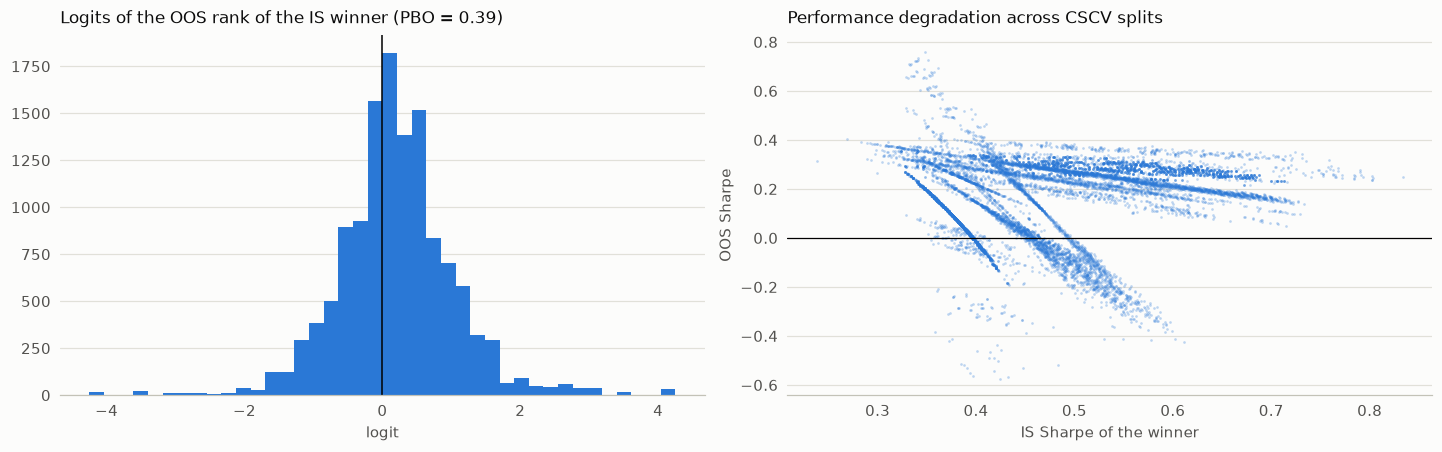

In [8]:
t0 = time.perf_counter()
pbo = st.probability_of_backtest_overfitting(grid_pnl.iloc[BURN_IN:], S=16)
print(f"PBO = {pbo['pbo']:.2f} over {pbo['n_combinations']:,} splits ({time.perf_counter() - t0:.2f} s)")
trial_sharpes = grid_pnl[in_sample].iloc[BURN_IN:].apply(lambda c: c.mean() / c.std(ddof=1))
dsr = mt.deflated_sharpe_ratio(grid_pnl[best][in_sample].iloc[BURN_IN:], trial_sharpes)
psr = mt.probabilistic_sharpe_ratio(grid_pnl[best][in_sample].iloc[BURN_IN:])
print(f"In-sample winner: PSR(0) = {psr:.3f}; deflated Sharpe ratio = {dsr['dsr']:.3f} "
      f"(benchmark {dsr['benchmark_sharpe'] * np.sqrt(252):.2f} annualised, {dsr['n_trials']} trials)")
boot = mt.bootstrap_sharpe(grid_pnl[best][~in_sample].to_numpy(), mean_block=20, n_boot=10_000, seed=SEED)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Out-of-sample Sharpe {mt.sharpe_ratio(grid_pnl[best][~in_sample]):.2f}, 95% bootstrap interval [{lo:.2f}, {hi:.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(pbo["logit"], bins=40, color=SERIES[0])
axes[0].axvline(0, color="k", lw=1)
axes[0].set(title=f"Logits of the OOS rank of the IS winner (PBO = {pbo['pbo']:.2f})", xlabel="logit")
axes[1].scatter(np.asarray(pbo["is_sharpe"]) * np.sqrt(252), np.asarray(pbo["oos_sharpe"]) * np.sqrt(252), s=3, alpha=0.3,
                lw=0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(title="Performance degradation across CSCV splits", xlabel="IS Sharpe of the winner", ylabel="OOS Sharpe")
fig.savefig(OUTPUT_DIR / "overfitting.png", dpi=150)

## 8. Robust variants: walk-forward re-estimation and adaptive standardisation

Section 3 showed that the dispersion of $z$ drifts away from 1 when the hyperparameters stay frozen at their 1988-2009 estimates.
Two remedies that use only past information:

- **Walk-forward re-estimation**: at the start of each year $Y$ the hyperparameters are re-estimated by maximum likelihood on all
  data up to 31 December of $Y-1$ (expanding window), and the signals of year $Y$ come from the filter run with them.
- **Adaptive z-score**: the forecast error is divided by the square root of an exponentially weighted average of past squared errors
  (half-life 60 days, information up to $t-1$) instead of the model's forecast variance $S_t$.

The trading rule is the textbook one of section 4 (entry 2.0, exit 0.5), so no threshold is tuned: the comparison isolates the effect
of the signal construction. Both remedies are tested in the package for the absence of look-ahead.

Walk-forward: 16 yearly re-estimations in 0.5 s


,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
delta (state noise),4.53e-04,4.09e-04,3.83e-04,3.44e-04,3.04e-04,2.80e-04,2.83e-04,2.74e-04,2.56e-04,2.45e-04,2.32e-04,7.16e-05,6.78e-05,6.68e-05,6.28e-05,6.06e-05
observation variance,3.78e-02,4.59e-02,5.17e-02,6.15e-02,7.34e-02,8.21e-02,8.44e-02,9.07e-02,9.72e-02,1.02e-01,1.09e-01,9.99e-01,9.74e-01,9.64e-01,9.48e-01,9.35e-01


s.d. of z (OOS)  annual P&L (USD)  \
hyperparameters  standardisation                                      
frozen 1988-2009 model z                   2.4092            2.8465   
                 adaptive z                1.1058            1.4375   
walk-forward     model z                   2.1826            2.7163   
                 adaptive z                1.1068            2.3159   

                                  Sharpe OOS  Sharpe OOS ex Apr-May 2020  \
hyperparameters  standardisation                                           
frozen 1988-2009 model z              0.2269                      0.1899   
                 adaptive z           0.2347                      0.1169   
walk-forward     model z              0.2124                      0.0201   
                 adaptive z           0.4170                      0.3025   

                                  max drawdown (USD)  position changes (OOS)  
hyperparameters  standardisation                                              
frozen 1988-2009 model z                      9.6716                 94.0000  
                 adaptive z                  27.4980                332.0000  
walk-forward     model z                     11.1082                130.0000  
                 adaptive z                  21.3633                332.0000

Best variant out of sample: walk-forward / adaptive z (Sharpe 0.42, +0.19 versus the frozen model z-score).
Four variants were compared: the choice among them is itself a (small) selection, and the differences should be read against the bootstrap interval of section 7.


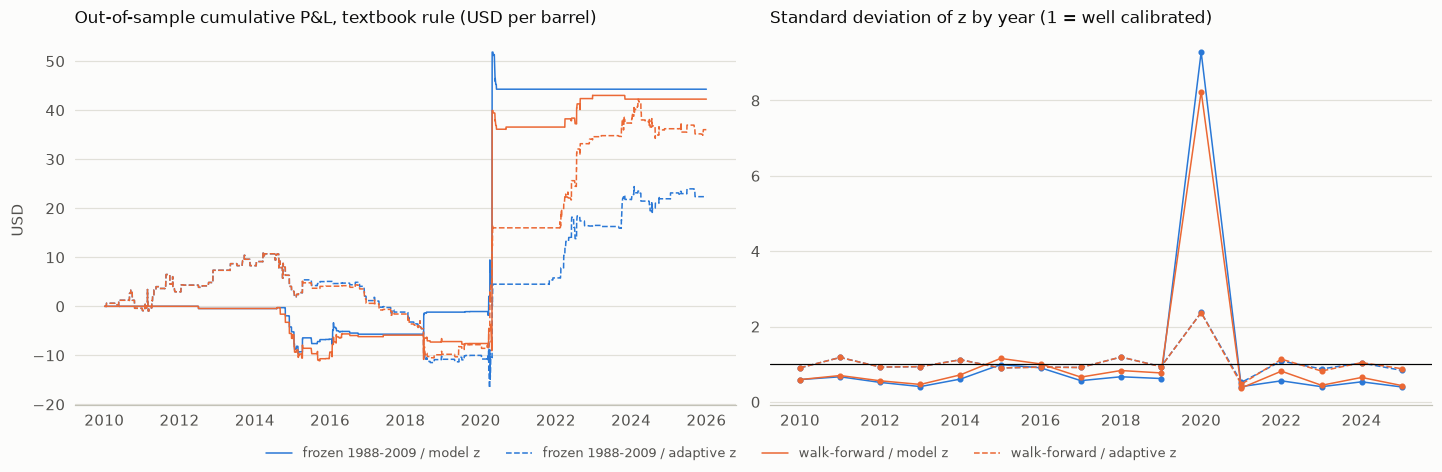

In [9]:
t0 = time.perf_counter()
first_oos_year = int(IN_SAMPLE_END[:4]) + 1
wf_signal, wf_params = st.walk_forward_kalman(y, x, first_year=first_oos_year, burn_in=BURN_IN)
print(f"Walk-forward: {len(wf_params)} yearly re-estimations in {time.perf_counter() - t0:.1f} s")
display(wf_params[["delta", "obs_var"]].rename(columns={"delta": "delta (state noise)", "obs_var": "observation variance"}).T
        .style.format("{:.2e}"))

variants = {
    ("frozen 1988-2009", "model z"): signal,
    ("frozen 1988-2009", "adaptive z"): signal.assign(z=st.adaptive_zscore(signal, halflife=Z_HALFLIFE)),
    ("walk-forward", "model z"): wf_signal,
    ("walk-forward", "adaptive z"): wf_signal.assign(z=st.adaptive_zscore(wf_signal, halflife=Z_HALFLIFE)),
}
rows, curves = {}, {}
for key, sig in variants.items():
    bt = st.pairs_backtest(y, x, sig, entry=2.0, exit=0.5, stop=STOP, cost_per_unit=COST_PER_BARREL, lag=LAG, start=BURN_IN)
    pnl_oos = bt["pnl"][~in_sample]
    curves[" / ".join(key)] = pnl_oos.cumsum()
    rows[key] = {"s.d. of z (OOS)": sig["z"][~in_sample].std(),
                 "annual P&L (USD)": pnl_oos.mean() * 252,
                 "Sharpe OOS": mt.sharpe_ratio(pnl_oos),
                 "Sharpe OOS ex Apr-May 2020": mt.sharpe_ratio(bt["pnl"][~in_sample & ~episode]),
                 "max drawdown (USD)": mt.max_drawdown(pnl_oos.cumsum()),
                 "position changes (OOS)": int((bt["units_y"][~in_sample].diff().fillna(0) != 0).sum())}
robust = pd.DataFrame(rows).T
robust.index.names = ["hyperparameters", "standardisation"]
display(robust)

by_year = pd.DataFrame({" / ".join(k): v["z"][~in_sample].groupby(v.index[~in_sample].year).std() for k, v in variants.items()})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
# Composite encoding: hue = hyperparameters (frozen or walk-forward), line style = standardisation of z.
def variant_style(name):
    hyper, standard = name.split(" / ")
    return {"color": SERIES[0] if hyper.startswith("frozen") else SERIES[1],
            "ls": "-" if standard.startswith("model") else "--"}

for name, curve in curves.items():
    axes[0].plot(curve.index, curve.to_numpy(), lw=1.0, label=name, **variant_style(name))
axes[0].set(title="Out-of-sample cumulative P&L, textbook rule (USD per barrel)", ylabel="USD")
for name in by_year:
    axes[1].plot(by_year.index, by_year[name], marker="o", ms=3, lw=1.0, **variant_style(name))
axes[1].axhline(1, color="k", lw=0.8)
axes[1].set(title="Standard deviation of z by year (1 = well calibrated)", xlabel="")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=4)
fig.savefig(OUTPUT_DIR / "robust_variants.png", dpi=150)

best_key = robust["Sharpe OOS"].idxmax()
gain = robust.loc[best_key, "Sharpe OOS"] - robust.loc[("frozen 1988-2009", "model z"), "Sharpe OOS"]
print(f"Best variant out of sample: {' / '.join(best_key)} (Sharpe {robust.loc[best_key, 'Sharpe OOS']:.2f}, "
      f"{gain:+.2f} versus the frozen model z-score).")
print("Four variants were compared: the choice among them is itself a (small) selection, and the differences should be read "
      "against the bootstrap interval of section 7.")

## 9. Interpretation guide

- The rolling Engle-Granger test shows that the WTI-Brent relation is not constant: infrastructure bottlenecks at Cushing
  (2011-2013) and the end of the US crude export ban (December 2015) moved the spread for long periods, which a static hedge ratio
  cannot follow; the Kalman filter adapts, at the cost of estimation noise.
- Heavy tails in $z$ (large excess kurtosis) mean that a normal-theory reading of the thresholds understates the frequency of large
  deviations; the stop-loss limits the damage. Single episodes, such as the negative WTI price of April 2020, can dominate the
  profit and loss of the whole out-of-sample period: always check results with and without them.
- With hyperparameters frozen at their 1988-2009 estimates, the standard deviation of $z$ drifts away from 1: the model's forecast
  variance is miscalibrated and the thresholds are hit too rarely (or too often). Section 8 shows that the adaptive z-score restores
  the calibration and that yearly re-estimation lets the filter follow structural breaks; neither turns a weak edge into a strong one,
  and the gain must be judged against the width of the bootstrap interval.
- Costs of one or two ticks per barrel already absorb a large share of the gross profit of fast configurations, and a one-day
  execution lag matters for a mean-reverting signal.
- A PBO well above zero, a deflated Sharpe ratio far from 1 and a bootstrap interval that includes zero are the honest summary of a
  grid search: the best in-sample configuration is only weak evidence of a durable edge.

Figures are saved in `outputs/wti_brent_pairs/`.

### References

- Bailey, D. H., Borwein, J., Lopez de Prado, M. and Zhu, Q. J. (2017). The probability of backtest overfitting. *Journal of Computational Finance*, 20(4), 39-69.
- Bailey, D. H. and Lopez de Prado, M. (2014). The deflated Sharpe ratio: correcting for selection bias, backtest overfitting and non-normality. *Journal of Portfolio Management*, 40(5), 94-107.
- Chan, E. (2013). *Algorithmic Trading: Winning Strategies and Their Rationale*. Wiley.
- Engle, R. F. and Granger, C. W. J. (1987). Co-integration and error correction: representation, estimation, and testing. *Econometrica*, 55(2), 251-276.
- Gatev, E., Goetzmann, W. N. and Rouwenhorst, K. G. (2006). Pairs trading: performance of a relative-value arbitrage rule. *Review of Financial Studies*, 19(3), 797-827.
- MacKinnon, J. G. (2010). Critical values for cointegration tests. Queen's Economics Department Working Paper 1227.
- Politis, D. N. and Romano, J. P. (1994). The stationary bootstrap. *Journal of the American Statistical Association*, 89(428), 1303-1313.
- U.S. Energy Information Administration, spot prices, retrieved from FRED, Federal Reserve Bank of St. Louis: https://fred.stlouisfed.org/series/DCOILWTICO and https://fred.stlouisfed.org/series/DCOILBRENTEU